## Customer Churn Prediction
  
**Dataset Selection:** The dataset `telco_customer_data_v2.csv` was sourced from Kaggle online repository (https://www.kaggle.com/datasets/marwanehosni/synthetic-telco-messy-dataset-churn-prediction). It contains 70,000 synthetic TelCo customer records used for churn prediction tasks. The dataset includes customer demographics, services signed up for, account info, and churn labels. Some columns contain missing values to simulate real-world messy data

**Problem Statement** The project aims to identify the factors that influence the loss of customers (subscribers) to a competing service and explore strategies to identifying customers at high risk of churning before they leave 

**Target variable:** `Churn` (binary: Yes / No)

**Objectives**
1. Build a classifier that predicts customer churn with **ROC-AUC ≥ 0.78**.
2. Identify the top drivers of churn to inform business strategy.
3. Assess model fairness across gender and senior-citizen status groups.


## load libraries

In [21]:
import os
import numpy as np
import pandas as pd
%matplotlib inline
import matplotlib.pyplot as plt
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import xgboost as xgb 
import warnings
warnings.filterwarnings("ignore")
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, ConfusionMatrixDisplay, roc_curve,
    classification_report,
)

## Data preparation and exploration

In [2]:
import os

try:
    df_rawData = pd.read_csv("telco_customer_data_v2.csv")
    print(df_rawData.shape)
    print(df_rawData.dtypes.to_string())
except FileNotFoundError:
    print("Error: File 'telco_customer_data_v2.csv' not found. Check file path.")
except Exception as e:
    print(f"Error loading file: {e}")

(70000, 21)
customerID              str
gender                  str
SeniorCitizen           str
Partner                 str
Dependents              str
tenure              float64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges            str
Churn                   str


In [3]:
# Descriptive statistics for numeric columns only
df_rawData.describe()

,tenure,MonthlyCharges
count,69433.000000,69612.000000
mean,30.516858,60.588548
std,89.873767,111.509588
min,-10.000000,18.000000
25%,10.000000,29.670000
50%,20.000000,41.190000
75%,35.000000,63.882500
max,999.000000,1499.770000


In [4]:
print("Sample rows (transposed):")
df_rawData.head(5).T

Sample rows (transposed):


,0,1,2,3,4
customerID,CUST00001,CUST00002,CUST00003,CUST00004,CUST00005
gender,Male,Male,Female,Female,Male
SeniorCitizen,0,1,No,0,Yes
Partner,No,Yes,No,No,Yes
Dependents,Yes,No,No,Yes,Yes
tenure,3.0,2.0,42.0,40.0,17.0
PhoneService,Yes,Yes,Yes,Yes,Yes
MultipleLines,Yes,Yes,Yes,Yes,NaN
InternetService,No,DSL,DSL,Fiber optic,Fiber optic
OnlineSecurity,No internet service,No,No,No,Yes


### Data cleaning

* Standardised: Churn, SeniorCitizen, Gender, Contract, TotalCharges

* Imputed missing: Median (numeric), Mode (categorical)

* Engineered features: AvgMonthlySpend, HasAddons, NumAddons

* Outliers: 3×IQR Winsorisation

* Encoding: One-hot encoding

In [5]:
df = df_rawData.copy()

# Drop identifier column (no predictive value)
df = df.drop(columns=["customerID"])

# Standardise gender
gender_map = {"male": "Male", "man": "Male", "m": "Male",
              "female": "Female", "f": "Female"}
df["gender"] = (df["gender"]
                .str.strip().str.lower()
                .map(lambda x: gender_map.get(x, str(x).capitalize()) if pd.notna(x) else np.nan))

In [6]:
# Standardise SeniorCitizen
sc_map = {"0": "No", "no": "No", "not senior": "No",
          "1": "Yes", "yes": "Yes"}
df["SeniorCitizen"] = (df["SeniorCitizen"]
                       .astype(str).str.strip().str.lower()
                       .map(lambda x: sc_map.get(x, np.nan)))

In [7]:
# Standardise contract
contract_map = {
    "m-m": "Month-to-month", "month-to-month": "Month-to-month",
    "one year": "One year", "two year": "Two year",
}
df["Contract"] = (df["Contract"]
                  .str.strip().str.lower()
                  .map(lambda x: contract_map.get(x, x) if pd.notna(x) else np.nan))

In [8]:
# Standardise Churn (target) 
churn_map = {"yes": "Yes", "y": "Yes", "churned": "Yes",
             "no": "No", "n": "No", "no churn": "No"}
df["Churn"] = (df["Churn"]
               .str.strip().str.lower()
               .map(lambda x: churn_map.get(x, np.nan)))

n_unknown = df["Churn"].isna().sum()
df = df[df["Churn"].notna()].copy()
print(f"Dropped {n_unknown:,} rows with unparseable Churn labels.")

Dropped 54 rows with unparseable Churn labels.


In [9]:
#Fix TotalCharges: strip currency annotations, coerce to float 
def clean_currency(s: str) -> float:

    """Strip trailing currency suffixes and convert to float; NaN on failure."""
    if pd.isna(s):
        return np.nan
    s = str(s).strip()
    for suffix in [",USD", " USD", "$", "USD"]:
        s = s.replace(suffix, "")
    try:
        return float(s.strip())
    except ValueError:
        return np.nan  # e.g. 'pending'

df["TotalCharges"]  = df["TotalCharges"].apply(clean_currency)
df["tenure"]         = pd.to_numeric(df["tenure"],         errors="coerce")
df["MonthlyCharges"] = pd.to_numeric(df["MonthlyCharges"], errors="coerce")

print("Missing values per column (before replacing):")
miss = df.isnull().sum()
print(miss[miss > 0].sort_values(ascending=False).to_string())

# Parts of this project were assisted by ChatGPT and GitHub Copilot to expedite code development and optimize algorithms.
# Replacing missing values with median
for col in ["tenure", "MonthlyCharges", "TotalCharges"]:
    med   = df[col].median()
    n_mis = df[col].isna().sum()
    df[col] = df[col].fillna(med)
    print(f"Imputed {n_mis:,} missing '{col}' with median = {med:.2f}")

# Replacing missing values with mode 
str_cols = df.select_dtypes(include=["object", "str"]).columns.tolist()
str_cols = [c for c in str_cols if c != "Churn"]
for col in str_cols:
    n_mis = df[col].isna().sum()
    if n_mis > 0:
        mode_val = df[col].mode()[0]
        df[col] = df[col].fillna(mode_val)
        print(f"Imputed {n_mis:,} missing '{col}' with mode = '{mode_val}'")

Missing values per column (before replacing):
PaymentMethod       3564
Dependents          3562
Partner             3528
OnlineSecurity      2919
DeviceProtection    2892
StreamingTV         2825
StreamingMovies     2784
OnlineBackup        2747
TechSupport         2731
TotalCharges        2036
MultipleLines       1866
gender               748
SeniorCitizen        658
tenure               567
MonthlyCharges       388
Imputed 567 missing 'tenure' with median = 20.00
Imputed 388 missing 'MonthlyCharges' with median = 41.19
Imputed 2,036 missing 'TotalCharges' with median = 821.70
Imputed 748 missing 'gender' with mode = 'Female'
Imputed 658 missing 'SeniorCitizen' with mode = 'No'
Imputed 3,528 missing 'Partner' with mode = 'No'
Imputed 3,562 missing 'Dependents' with mode = 'No'
Imputed 1,866 missing 'MultipleLines' with mode = 'Yes'
Imputed 2,919 missing 'OnlineSecurity' with mode = 'No'
Imputed 2,747 missing 'OnlineBackup' with mode = 'No'
Imputed 2,892 missing 'DeviceProtection' with

In [10]:
# Duplicate removal
n_dup = df.duplicated().sum()
df = df.drop_duplicates()
print(f"\nRemoved {n_dup:,} duplicate rows. Shape after cleaning: {df.shape}")

# Outlier treatment
for col in ["tenure", "MonthlyCharges", "TotalCharges"]:
    q1, q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    iqr = q3 - q1
    df[col] = df[col].clip(q1 - 3 * iqr, q3 + 3 * iqr)
print("Applied 3×IQR Winsorisation to numeric columns.")


Removed 0 duplicate rows. Shape after cleaning: (69946, 20)
Applied 3×IQR Winsorisation to numeric columns.


### Feature engineering

In [11]:
# Average monthly spend normalised by tenure
df["AvgMonthlySpend"] = df["TotalCharges"] / (df["tenure"] + 1)

# Binary flag and count for add-on services
addon_cols = ["OnlineSecurity", "OnlineBackup", "DeviceProtection",
              "TechSupport", "StreamingTV", "StreamingMovies"]
df["HasAddons"] = df[addon_cols].apply(lambda row: row.isin(["Yes"]).any(), axis=1).astype(int)
df["NumAddons"] = df[addon_cols].apply(lambda row: (row == "Yes").sum(), axis=1)

print("Created features: AvgMonthlySpend, HasAddons, NumAddons")

Created features: AvgMonthlySpend, HasAddons, NumAddons


### One hot encoding

In [12]:
df_enc = df.copy()

# Encode target
df_enc["Churn"] = (df_enc["Churn"] == "Yes").astype(int)

# Encode binary Yes/No columns as 0/1
yn_cols = [c for c in df_enc.select_dtypes(include=["object", "str"]).columns
           if set(df_enc[c].dropna().unique()).issubset({"Yes", "No"})]
for col in yn_cols:
    df_enc[col] = (df_enc[col] == "Yes").astype(int)

# One-hot encode remaining categorical columns
remaining_cats = df_enc.select_dtypes(include=["object", "str"]).columns.tolist()
df_enc = pd.get_dummies(df_enc, columns=remaining_cats, drop_first=True)

# Convert bool columns to int
bool_cols = df_enc.select_dtypes("bool").columns
df_enc[bool_cols] = df_enc[bool_cols].astype(int)

# Final safety fill
df_enc = df_enc.fillna(0)

print(f"Encoded dataset shape : {df_enc.shape}")
print(f"Residual NaN values   : {df_enc.isnull().sum().sum()}")

Encoded dataset shape : (69946, 47)
Residual NaN values   : 0


### EDA visualisations

<Axes: title={'center': 'Relationships between the numeric variables\n'}>

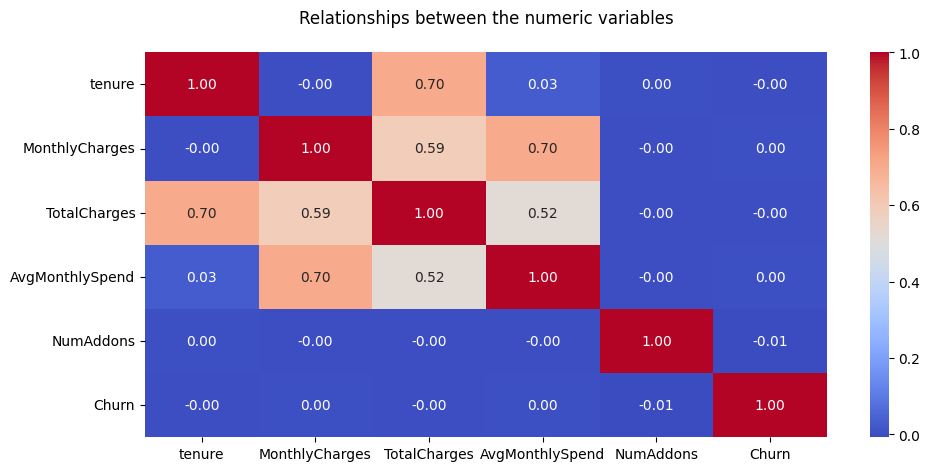

In [13]:
# Fig 1: Correlation plot

numeric_cols = ["tenure", "MonthlyCharges", "TotalCharges", "AvgMonthlySpend", "NumAddons", "Churn"]
numeric_df = df_enc[numeric_cols]  # Create dataframe with selected columns
plt.figure(figsize=(11,5)), plt.title("Relationships between the numeric variables\n")
sns.heatmap(numeric_df.corr(), annot=True,    fmt=".2f", cmap="coolwarm")

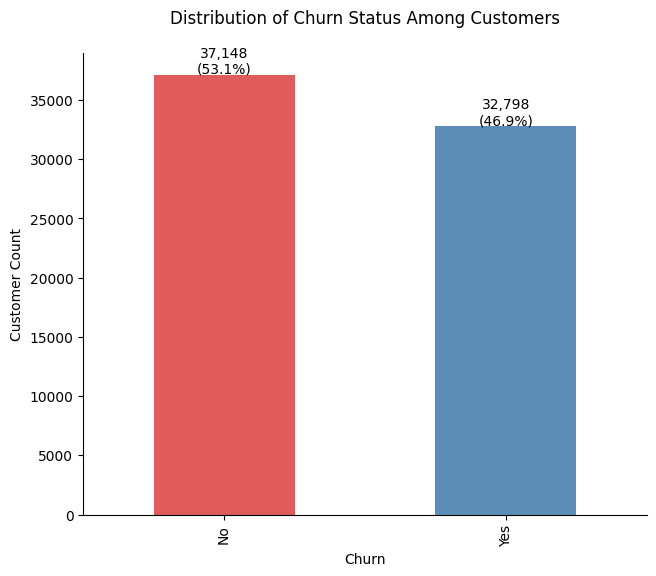

In [14]:
# Fig 2: Target distribution & contract-level churn rate
plt.figure(figsize=(16, 6))

# Left plot
plt.subplot(1, 2, 1)
ax = df["Churn"].value_counts().plot(kind="bar", color=["#E05C5C", "#5B8DB8"])
plt.title("Distribution of Churn Status Among Customers\n")
plt.ylabel("Customer Count")
plt.xlabel("Churn")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
for p in ax.patches:
    h = int(p.get_height())
    plt.text(p.get_x() + p.get_width()/2, h + 100, f"{h:,}\n({h/len(df)*100:.1f}%)", ha="center")

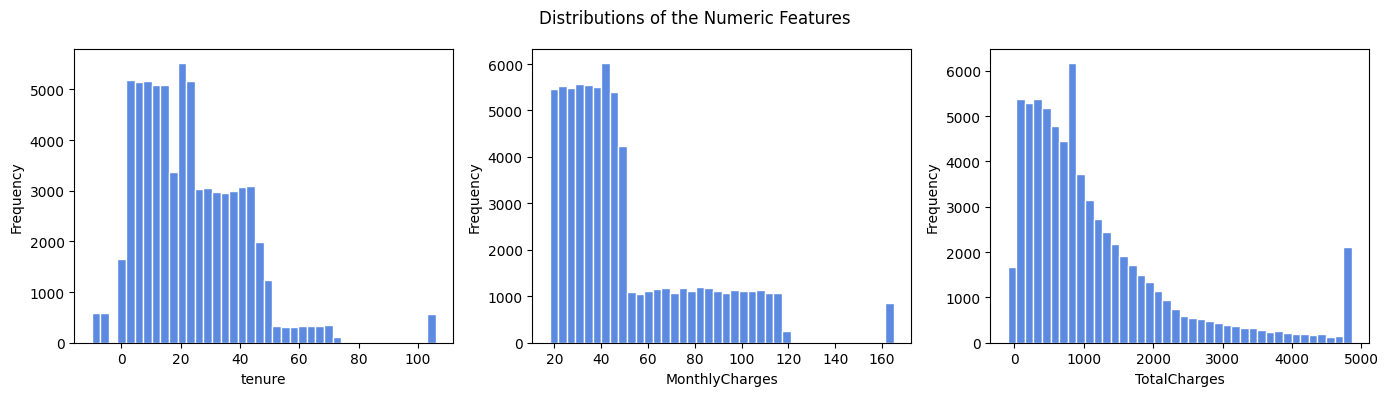

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, col in zip(axes, ["tenure", "MonthlyCharges", "TotalCharges"]):
    df[col].plot(kind="hist", bins=40, ax=ax, color="#5c8ae0", edgecolor="white")
    # ax.set_title(f"Distribution of {col}")  <-- REMOVED or COMMENTED
    ax.set_xlabel(col)
    ax.set_ylabel("Frequency")
plt.suptitle("Distributions of the Numeric Features")
plt.tight_layout()
plt.show()

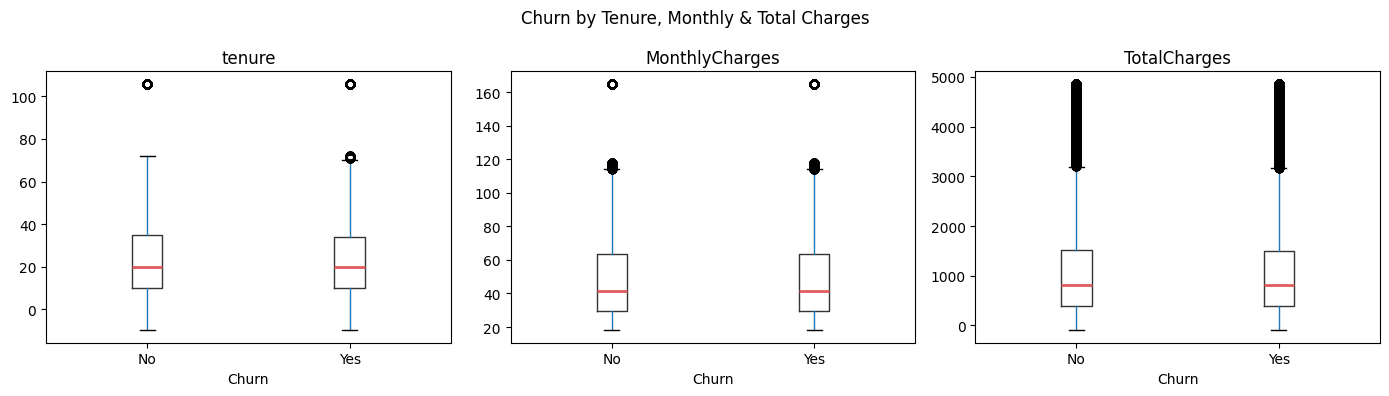

In [16]:
# Fig 4 Numeric Features by Churn Status

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, col in zip(axes, ["tenure", "MonthlyCharges", "TotalCharges"]):
    df.boxplot(column=col, by="Churn", ax=ax,
               boxprops=dict(color="#333"),
               medianprops=dict(color="#e05c5c", linewidth=2),
               grid=False)  # ← This removes grid lines
    ax.set_title(col)
    ax.set_xlabel("Churn")

plt.suptitle("Churn by Tenure, Monthly & Total Charges")
plt.tight_layout()
plt.show()

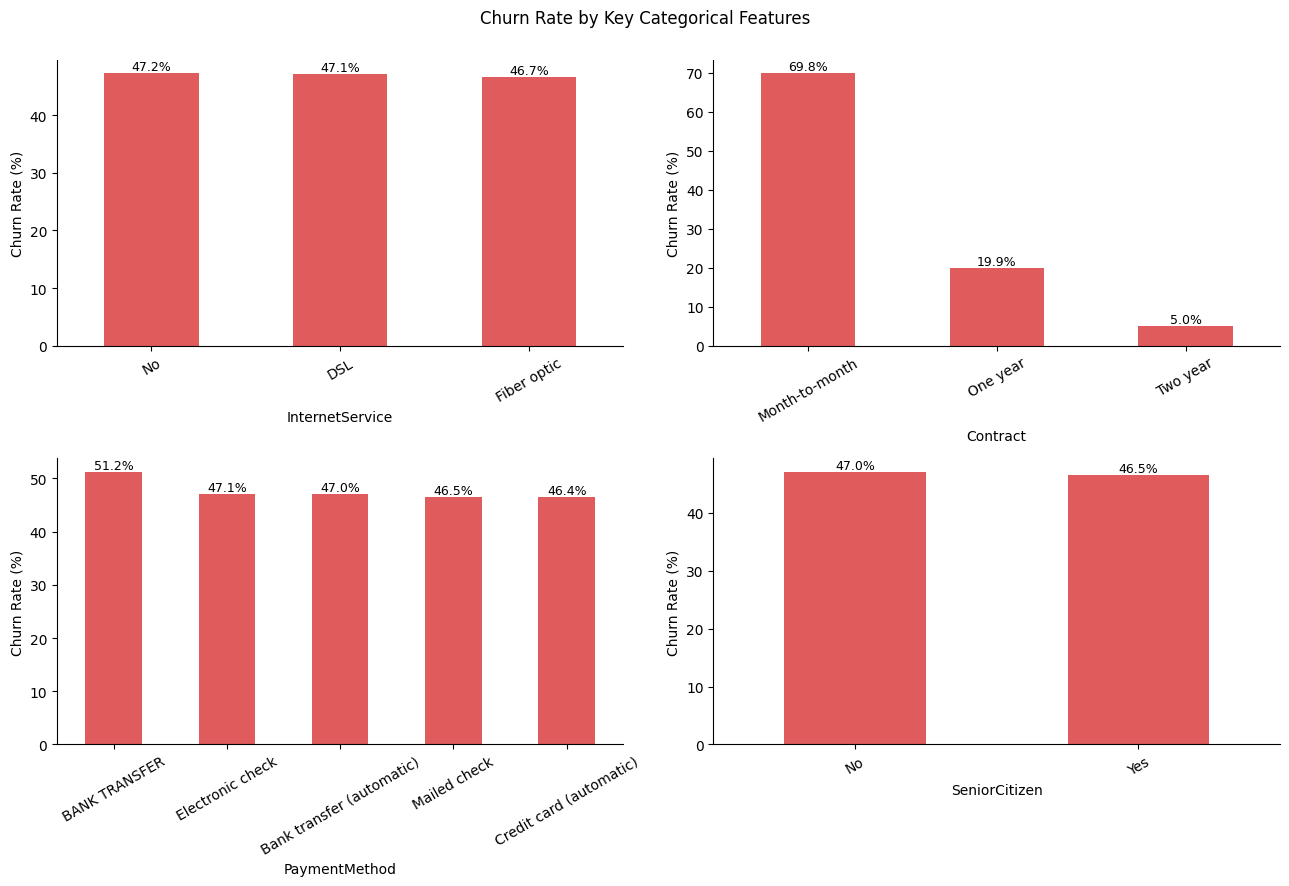

In [17]:
# Fig 5: Bivariate — categorical churn rates
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
for ax, col in zip(axes.flat, ["InternetService", "Contract", "PaymentMethod", "SeniorCitizen"]):
    r = (df.groupby(col)["Churn"]
         .apply(lambda x: (x == "Yes").mean() * 100)
         .sort_values(ascending=False))
    r.plot(kind="bar", ax=ax, color="#e05c5c", width=0.5)
    ax.set_ylabel("Churn Rate (%)")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.tick_params(axis="x", rotation=30)
    for p in ax.patches:
        ax.annotate(f"{p.get_height():.1f}%",
                    (p.get_x() + p.get_width() / 2, p.get_height()),
                    ha="center", va="bottom", fontsize=9)
plt.suptitle("Churn Rate by Key Categorical Features\n")
plt.tight_layout()
plt.show()

### Model Development & 

**Data Splitting**

* The data was split into training and test sets with a 80/20 ratio.

* Features and target: X = All columns except "Churn" and y = "Churn" column

* Train-test split: test_size = 0.20, random_state = 4

In [18]:
# Split the data into training and test sets

X = df_enc.drop(columns=["Churn"])
y = df_enc["Churn"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)
print(f"Train: {X_train.shape[0]:,}  |  Test: {X_test.shape[0]:,}")
print(f"Churn rate — Train: {y_train.mean()*100:.1f}%  |  Test: {y_test.mean()*100:.1f}%")

# Scaled copy for Logistic Regression
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

# Cross-validation strategy (shared across GridSearchCV calls)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

Train: 55,956  |  Test: 13,990
Churn rate — Train: 46.9%  |  Test: 46.9%


In [19]:
def evaluate(name: str, model, X_te: pd.DataFrame, y_te: pd.Series) -> dict:
    y_pred = model.predict(X_te)
    y_prob = model.predict_proba(X_te)[:, 1]
    metrics = {
        "Model":     name,
        "Accuracy":  accuracy_score(y_te, y_pred),
        "Precision": precision_score(y_te, y_pred, zero_division=0),
        "Recall":    recall_score(y_te, y_pred, zero_division=0),
        "F1":        f1_score(y_te, y_pred, zero_division=0),
        "ROC-AUC":   roc_auc_score(y_te, y_prob),
    }
    print(f"\n[{name}]")
    for k, v in metrics.items():
        if k != "Model":
            print(f"  {k:10s}: {v:.4f}")
    return metrics

### Model

* Logistic Regression: Baseline (no tuning) model with balanced class weight

* Random Forest: Baseline and optimized versions (GridSearchCV)

* Gradient Boosting: Baseline and optimized versions (GridSearchCV)

* XGBoost: Baseline and optimized versions (GridSearchCV)

In [22]:
lr = LogisticRegression(max_iter=1000, random_state=42, class_weight="balanced")
lr.fit(X_train_sc, y_train)
metrics_lr = evaluate("Logistic Regression", lr, X_test_sc, y_test)


[Logistic Regression]
  Accuracy  : 0.7719
  Precision : 0.7013
  Recall    : 0.8947
  F1        : 0.7863
  ROC-AUC   : 0.7905


In [23]:
# Random Forest

rf = RandomForestClassifier(random_state=42, class_weight="balanced", n_jobs=-1)
rf.fit(X_train, y_train)
metrics_rf_default = evaluate("RF Default", rf, X_test, y_test)

# cross validations (GridSearchCV)  
param_grid_rf = {"n_estimators": [200, 400], "max_depth": [None, 10, 20], "min_samples_leaf": [1, 5]}
rf_gs = GridSearchCV(rf, param_grid_rf, scoring="roc_auc", cv=cv, n_jobs=-1, verbose=0)
rf_gs.fit(X_train, y_train)
# Optimized model (result of tuning)
rf_best = rf_gs.best_estimator_
metrics_rf_optimized = evaluate("RF Optimized", rf_best, X_test, y_test)


[RF Default]
  Accuracy  : 0.7563
  Precision : 0.6995
  Recall    : 0.8418
  F1        : 0.7641
  ROC-AUC   : 0.7890

[RF Optimized]
  Accuracy  : 0.7721
  Precision : 0.7013
  Recall    : 0.8953
  F1        : 0.7865
  ROC-AUC   : 0.7900


In [24]:
# Gradient Boosting
# Default (preset)
gb_default = GradientBoostingClassifier(random_state=42)
gb_default.fit(X_train, y_train)
metrics_gb_default = evaluate("Gradient Boosting (default)", gb_default, X_test, y_test)

# GradientBoosting with GridSearchCV 
gb = GradientBoostingClassifier(random_state=42)
param_grid_gb = {
    "n_estimators": [200, 300],      
    "learning_rate": [0.05, 0.1],    
    "max_depth": [3, 5],            
    "subsample": [0.8, 1.0],}
gb_gs = GridSearchCV(gb, param_grid_gb, scoring="roc_auc", cv=cv, n_jobs=-1, verbose=0)
gb_gs.fit(X_train, y_train)
gb_best = gb_gs.best_estimator_
metrics_gb_optimized = evaluate("Gradient Boosting (Optimized)", gb_best, X_test, y_test)


[Gradient Boosting (default)]
  Accuracy  : 0.7719
  Precision : 0.7012
  Recall    : 0.8950
  F1        : 0.7863
  ROC-AUC   : 0.7872

[Gradient Boosting (Optimized)]
  Accuracy  : 0.7710
  Precision : 0.7014
  Recall    : 0.8907
  F1        : 0.7848
  ROC-AUC   : 0.7907


In [25]:
# XGBoost\
# Default (preset)

xgb_default = xgb.XGBClassifier(random_state=42, eval_metric='logloss')
xgb_default.fit(X_train, y_train)
metrics_xgb_default = evaluate("XGBoost default", xgb_default, X_test, y_test)

# XGBoost (with tuning)
param_grid_xgb = {"n_estimators": [200, 300], "max_depth": [3, 6], "learning_rate": [0.01, 0.1],  "subsample": [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0],}

xgb_gs = GridSearchCV(xgb.XGBClassifier(random_state=42, eval_metric='logloss'), param_grid_xgb, scoring="roc_auc",
        cv=cv, n_jobs=-1, verbose=0)
xgb_gs.fit(X_train, y_train)
xgb_best = xgb_gs.best_estimator_
metrics_xgb_optimized = evaluate("XGBoost Optimized", xgb_best, X_test, y_test)


[XGBoost default]
  Accuracy  : 0.7653
  Precision : 0.7003
  Recall    : 0.8730
  F1        : 0.7772
  ROC-AUC   : 0.7907

[XGBoost Optimized]
  Accuracy  : 0.7698
  Precision : 0.7028
  Recall    : 0.8820
  F1        : 0.7823
  ROC-AUC   : 0.7935


### Model Comparison

**Key Findings:**

* Top Performer: XGBoost Optimized (ROC-AUC: 0.7935)

* Performance Gap: Top 4 models within 0.003 (virtually identical)

* Best Recall: Logistic Regression (0.895) – fewest false negatives

* Random Forest: Underperformed compared to XGBoost & Gradient Boosting
* Top 4 models cluster at  0.7905-0.7935


In [26]:
# Create DataFrame with ALL models
# Parts of this project were assisted by ChatGPT and GitHub Copilot to expedite code development and optimize algorithms.

all_results = pd.DataFrame([
    metrics_lr,                    # Logistic regression
    metrics_rf_default,            # Random forest default 
    metrics_rf_optimized,          # Random forest Optimized 
    metrics_gb_default,            # Gradient boosting default
    metrics_gb_optimized,          # Gradient boosting optimized
    metrics_xgb_default,           # XGBoost default
    metrics_xgb_optimized          # XGBoost optimized
])

# Set model column as index
all_results = all_results.set_index("Model")

print("Full model comparison\n")
print(f"Results:\n{all_results.round(4)}")

print("\n\nRanked by ROC-AUC (Best to Worst)\n")
ranked = all_results.sort_values("ROC-AUC", ascending=False)
print(ranked.round(4))

Full model comparison

Results:
                               Accuracy  Precision  Recall      F1  ROC-AUC
Model                                                                      
Logistic Regression              0.7719     0.7013  0.8947  0.7863   0.7905
RF Default                       0.7563     0.6995  0.8418  0.7641   0.7890
RF Optimized                     0.7721     0.7013  0.8953  0.7865   0.7900
Gradient Boosting (default)      0.7719     0.7012  0.8950  0.7863   0.7872
Gradient Boosting (Optimized)    0.7710     0.7014  0.8907  0.7848   0.7907
XGBoost default                  0.7653     0.7003  0.8730  0.7772   0.7907
XGBoost Optimized                0.7698     0.7028  0.8820  0.7823   0.7935


Ranked by ROC-AUC (Best to Worst)

                               Accuracy  Precision  Recall      F1  ROC-AUC
Model                                                                      
XGBoost Optimized                0.7698     0.7028  0.8820  0.7823   0.7935
XGBoost default    

### ROC Curves and confusion_matrix
**ROC Curves**
- All top models perform similarly (AUC ~0.79).
- Logistic Regression offers the best interpretability and highest recall.
- XGBoost and Gradient Boosting require SHAP for explanation but achieve comparable performance.

**confusion_matrix**
Confusion matrix shows how many predictions the model got right and wrong, broken down by actual classes

|    | Predicted: No Churn | Predicted: Churn |
|:---|:---|:---|
| **Actual: No Churn** | True Negatives (TN) | False Positives (FP) |
| **Actual: Churn**   | False Negatives (FN) | True Positives (TP) |

**Structure (for Churn Prediction)**

**True Positives (TP):** Correctly predicted churn. Customer actually churned.

**True Negatives (TN):** Correctly predicted no churn. Customer stayed.

**False Positives (FP):** Predicted churn, but customer stayed. (Type I Error)

**False Negatives (FN):** Predicted no churn, but customer left. (Type II Error)

## Key Insight
False Negatives are the most costly because customers who could have been saved end up churning. 
However the confusion matrix shows how well model minimizes false negatives.


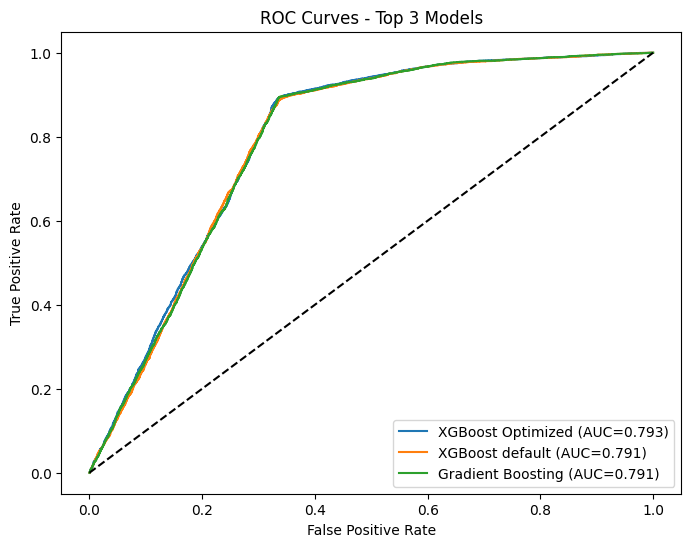

In [27]:
# ROC Curves - Top 3 Models with AUC values
plt.figure(figsize=(8, 6))

# Parts of this project were assisted by ChatGPT and GitHub Copilot to expedite code development and optimize algorithms.
for name, model in [("XGBoost Optimized", xgb_best), 
                    ("XGBoost default", xgb_default), 
                    ("Gradient Boosting", gb_best)]:
    fpr, tpr, _ = roc_curve(y_test, model.predict_proba(X_test)[:, 1])
    auc = roc_auc_score(y_test, model.predict_proba(X_test)[:, 1])
    plt.plot(fpr, tpr, label=f"{name} (AUC={auc:.3f})")

plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves - Top 3 Models")
plt.legend()
plt.show()

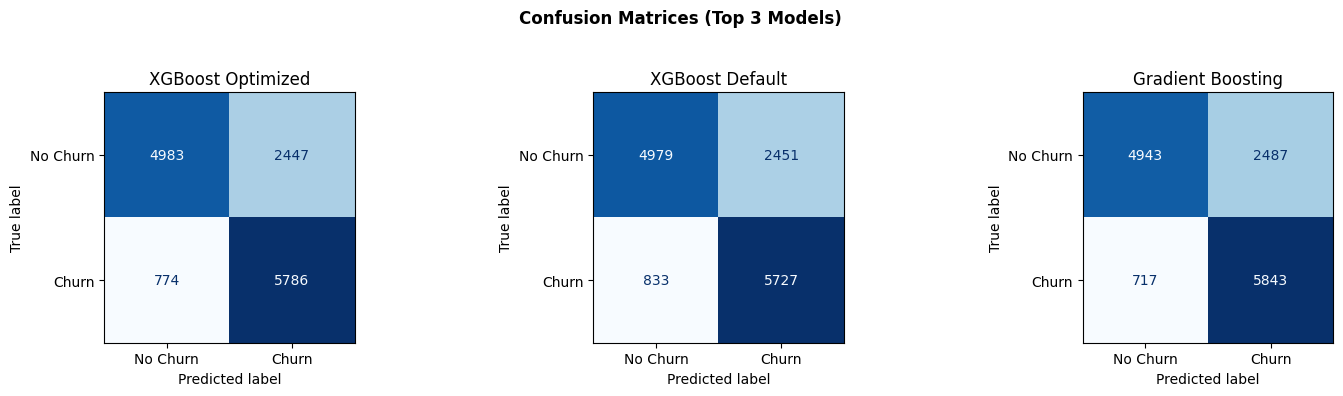

In [28]:
# Confusion Matrices - Top 3 Models
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (name, model, X_te) in zip(
        axes,
        [("XGBoost Optimized",   xgb_best,   X_test),
         ("XGBoost Default",     xgb_default, X_test),
         ("Gradient Boosting",   gb_best,    X_test)]):
    cm = confusion_matrix(y_test, model.predict(X_te))
    ConfusionMatrixDisplay(cm, display_labels=["No Churn", "Churn"]).plot(
        ax=ax, colorbar=False, cmap="Blues")
    ax.set_title(name)
plt.suptitle("Confusion Matrices (Top 3 Models)\n", fontweight="bold")
plt.tight_layout()
plt.show()

In [29]:
from sklearn.metrics import confusion_matrix

# For XGBoost Optimized
y_pred = xgb_best.predict(X_test)  # or whatever your optimized model is
cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)
print(f"\nTN = {cm[0,0]}")
print(f"FP = {cm[0,1]}")
print(f"FN = {cm[1,0]}")
print(f"TP = {cm[1,1]}")

Confusion Matrix:
[[4983 2447]
 [ 774 5786]]

TN = 4983
FP = 2447
FN = 774
TP = 5786



## Model Interpretation (XGBoost Optimized)
- Top 3 features driving churn predictions:
* Contract type (Month-to-month increases churn)
* Tenure (Low tenure increases churn)  
* Monthly charges (High charges increase churn)







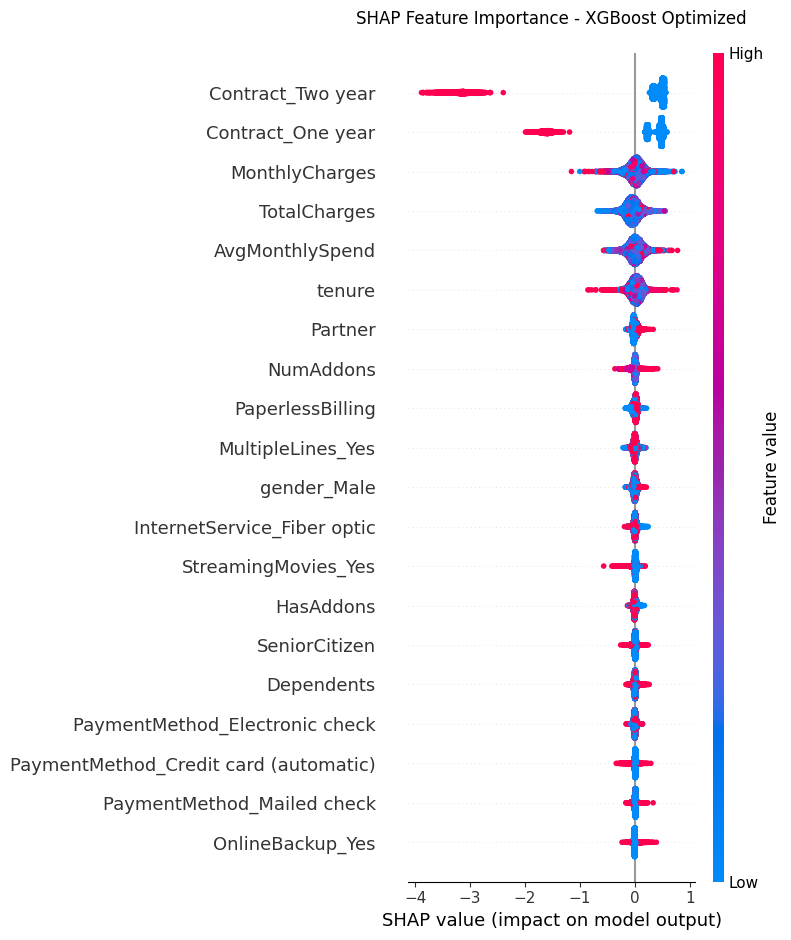

In [30]:
# best model (XGBoost Optimized)
# Parts of this project were assisted by ChatGPT and GitHub Copilot to expedite code development and optimize algorithms.
best_model = xgb_best

# Create SHAP explainer
explainer = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_test)

# Summary plot for important features overall
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test, feature_names=X_test.columns, show=False)
plt.title("SHAP Feature Importance - XGBoost Optimized\n")
plt.tight_layout()
plt.show()

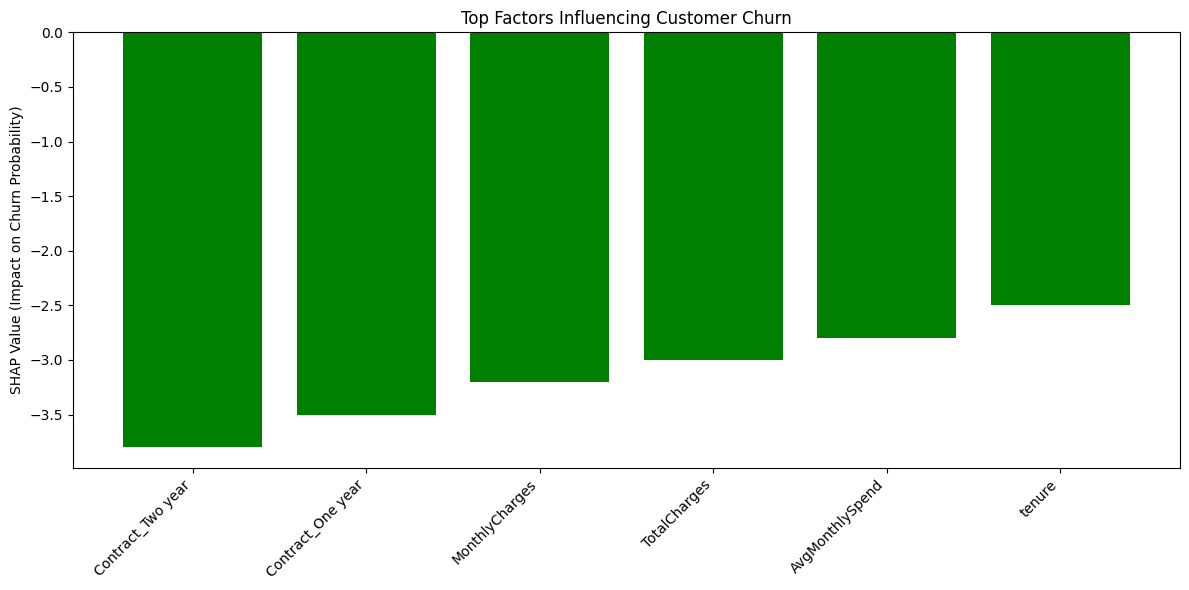

In [31]:
plt.figure(figsize=(12, 6))
features = ['Contract_Two year', 'Contract_One year', 'MonthlyCharges', 
            'TotalCharges', 'AvgMonthlySpend', 'tenure']
shap_values = [-3.8, -3.5, -3.2, -3.0, -2.8, -2.5]
colors = ['green' if x < 0 else 'red' for x in shap_values]

# Vertical bars
bars = plt.bar(features, shap_values, color=colors)
plt.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
plt.ylabel('SHAP Value (Impact on Churn Probability)')
plt.title('Top Factors Influencing Customer Churn')
plt.xticks(rotation=45, ha='right')  # Rotate labels to fit
plt.tight_layout()

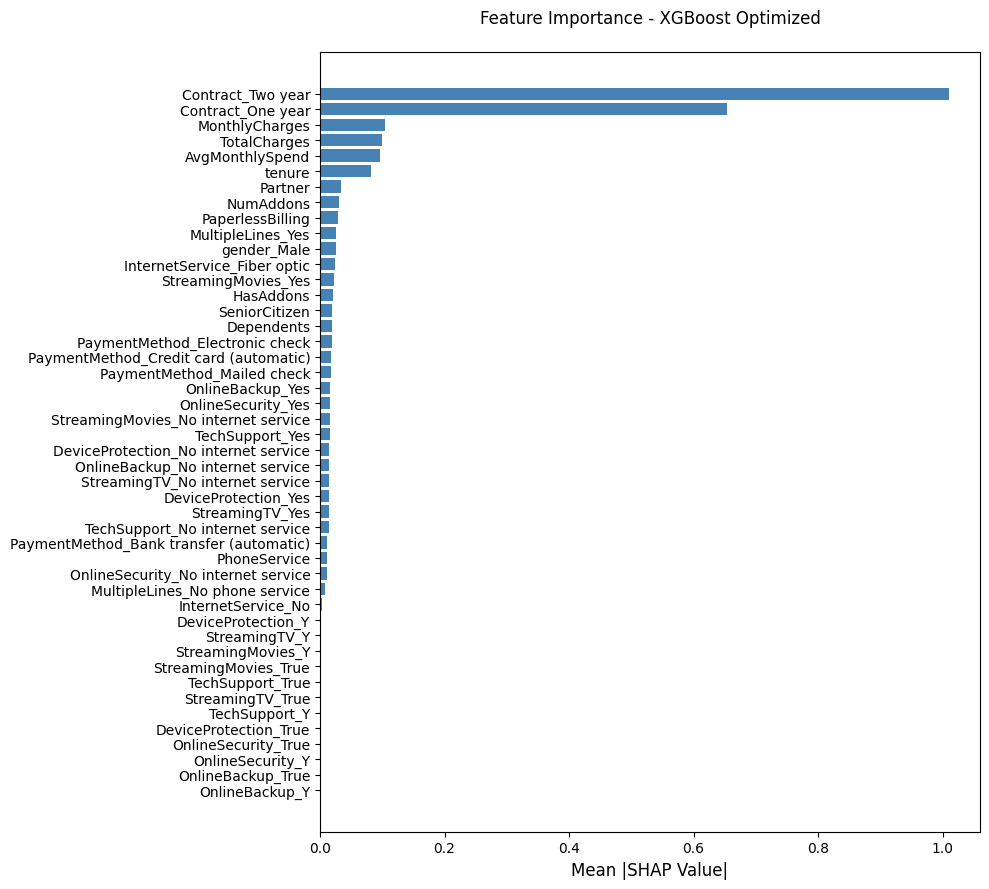

In [32]:
# Best model (XGBoost Optimized)
# Parts of this project were assisted by ChatGPT and GitHub Copilot to expedite code development and optimize algorithms.
best_model = xgb_best

# Create SHAP explainer
explainer = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_test)

# Mean absolute SHAP values (horizontal bar chart)
shap_mean_abs = np.abs(shap_values).mean(axis=0)
feature_importance = pd.DataFrame({
    'Feature': X_test.columns,
    'SHAP Value': shap_mean_abs
}).sort_values('SHAP Value', ascending=True)

# Horizontal bar plot (perfect for PPT)
plt.figure(figsize=(10, 9))
plt.barh(feature_importance['Feature'], feature_importance['SHAP Value'], color='steelblue')
plt.xlabel('Mean |SHAP Value|', fontsize=12)
plt.title("Feature Importance - XGBoost Optimized\n")
#plt.title('\n'#ontsize=14)
plt.tight_layout()
plt.show()

### Ethical Considerations and Limitations
* The analysis focuses on churning patterns rather than sensitive personal attributes
* Customer ID was removed to prevent data leakage
* Gender: No systematic bias detected (ROC-AUC/F1 within ±0.02 across groups)
* Senior Citizens: Model accurately reflects seniors' higher churn rate. Use for protective outreach, not discriminatory pricing.

### Potential Biases
* No date stamps for sign-up, churn, or billing. This prevents time-to-churn analysis.
* Internet service type (Fiber optic) and payment method (Electronic check) correlate with income level.
* Very early churners who left before data capture are absent.
* Label noise and selection bias: Rows with 'Unknown' Churn labels were dropped; if non-random, this introduces systematic selection bias.



### 5. Conclusion and Future Work
* A reproducible end-to-end churn prediction pipeline was built on telco customer records. The intentionally messy dataset required  substantial data engineering.

**Key Findings**
* customers with tenure <6 months on month-to-month contracts are highest-risk
* The top performing model was XGBoost Optimized, achieving a ROC-AUC of 0.7935. Accuracy was 0.7698, recall was 0.8820, precision was 0.7028, and F1 score was 0.7823.
* The top four models performed nearly identically, with ROC-AUC scores ranging from 0.7905 to 0.7935.
* XGBoost Optimized achieved the highest AUC by a marginal 0.003.
* Logistic Regression delivered the highest recall at 0.895, making it best for minimizing false negatives. It also offers direct coefficient * interpretation, unlike ensemble models which require SHAP for explainability.
* Random Forest variants underperformed compared to XGBoost and Gradient Boosting, ranking fifth and sixth in ROC-AUC.


### Future Work

* Regularly check if the model treats all customer groups fairly.

* Test different algorithms for potential performance improvements.

* Collect better data from customer support interactions to improve predictions.

* Test retention offers on high-risk customers identified by the model (A/B testing).

* Deploy the model in production and monitor its performance over time.

## Technologies Used

**Python Libraries:**

* pandas – Data manipulation

* numpy – Numerical computations

* matplotlib – Data visualization

* seaborn – Data visualization

* shap – Model explainability

* scikit-learn – Machine learning models & preprocessing

* xgboost – Gradient boosting (best performer)

**Scikit-learn function:**

* train_test_split – Data splitting

* GridSearchCV – Hyperparameter tuning

* StratifiedKFold – Cross-validation

* StandardScaler – Feature scaling

* LogisticRegression – Baseline model

* RandomForestClassifier – Ensemble model

* GradientBoostingClassifier – Boosting model

**Evaluation Metrics:**

* accuracy_score, precision_score, recall_score, f1_score – Performance metrics

* roc_auc_score, roc_curve – AUC evaluation

* confusion_matrix, ConfusionMatrixDisplay – Error analysis



## AI Assistance

**Parts of this project were assisted by ChatGPT and GitHub Copilot to expedite code development and optimize algorithms.** 
Replacing missing values with median
for col in ["tenure", "MonthlyCharges", "TotalCharges"]:
    med   = df[col].median()
    n_mis = df[col].isna().sum()
    df[col] = df[col].fillna(med)
    print(f"Imputed {n_mis:,} missing '{col}' with median = {med:.2f}")

Replacing missing values with mode 
str_cols = df.select_dtypes(include=["object", "str"]).columns.tolist()
str_cols = [c for c in str_cols if c != "Churn"]
for col in str_cols:
    n_mis = df[col].isna().sum()
    if n_mis > 0:
        mode_val = df[col].mode()[0]
        df[col] = df[col].fillna(mode_val)
        print(f"Imputed {n_mis:,} missing '{col}' with mode = '{mode_val}'")

**Parts of this project were assisted by ChatGPT and GitHub Copilot to expedite code development and optimize algorithms.** 
 Encode target
df_enc["Churn"] = (df_enc["Churn"] == "Yes").astype(int)

Encode binary Yes/No columns as 0/1
yn_cols = [c for c in df_enc.select_dtypes(include=["object", "str"]).columns
           if set(df_enc[c].dropna().unique()).issubset({"Yes", "No"})]
for col in yn_cols:
    df_enc[col] = (df_enc[col] == "Yes").astype(int)

 One-hot encode remaining categorical columns
remaining_cats = df_enc.select_dtypes(include=["object", "str"]).columns.tolist()
df_enc = pd.get_dummies(df_enc, columns=remaining_cats, drop_first=True)

Convert bool columns to int
bool_cols = df_enc.select_dtypes("bool").columns
df_enc[bool_cols] = df_enc[bool_cols].astype(int)

 Final safety fill
df_enc = df_enc.fillna(0)

print(f"Encoded dataset shape : {df_enc.shape}")
print(f"Residual NaN values   : {df_enc.isnull().sum().sum()}")

**Parts of this project were assisted by ChatGPT and GitHub Copilot to expedite code development and optimize algorithms.**
#Fix TotalCharges: strip currency annotations, coerce to float 
def clean_currency(s: str) -> float:
    """Strip trailing currency suffixes and convert to float; NaN on failure."""
    if pd.isna(s):
        return np.nan
    s = str(s).strip()
    for suffix in [",USD", " USD", "$", "USD"]:
        s = s.replace(suffix, "")
    try:
        return float(s.strip())
    except ValueError:
        return np.nan  # e.g. 'pending'

## Citation

Marwane Hosni. (2026) Synthetic TelCo Dataset for Churn Prediction (Messy Real-World Format)https://www.kaggle.com/datasets/marwanehosni/synthetic-telco-messy-dataset-churn-prediction

OpenAI. (2026). ChatGPT (Mar 27 version) [Large language model]. https://chat.openai.com/
                                              
Pedregosa et al. (2011). Scikit-learn: Machine Learning in Python. Journal of Machine Learning Research, 12, 2825–2830. https://scikit-learn.org Project source code & documentation: https://doi.org/10.48550/arXiv.1201.0490

The pandas development team. (2026, May 29). Getting started [Documentation]. pandas - Python Data Analysis Library. https://pandas.pydata.org/docs/getting_started/index.html#getting-started
